In [370]:
import pandas as pd
import seaborn as sns
import glob
import matplotlib
from matplotlib import pyplot as plt
from redim.pca import PCAresult
from redim.kpca import kPCAresult
from redim.umap import UMAPresult
from redim.tsne import tSNEresult


In [371]:
def assign_max_phase(status:str):
    if "Approved" in status or "Apprpved" in status:
        return "Approved"
    elif "Phase 3" in status or "New Drug Application" in status:
        return "Phase 3"
    elif "Phase 2" in status:
        return "Phase 2"
    elif "Phase 1" in status:
        return "Phase 1"
    elif ("Investigative" in status) or ("Investigational" in status):
        return "Investigative"
    else:
        print(f"Unknown phase: {status}")
        return "Unknown"

MAX_PHASE_COLORS = {
    "Approved": "#2ca02c",
    "Phase 3": "#1f77b4",
    "Phase 2": "#ff7f0e",
    "Phase 1": "#d62728",
    "Investigative": "#9467bd",
    "Unknown": "#7f7f7f"
}

def assign_approved(status:str):
    if "Approved" in status or "Apprpved" in status:
        return "Approved"
    else:
        return "Not Approved (yet?)"

APPROVED_COLORS = {
    "Approved": "#2ca02c",
    "Not Approved (yet?)": "#d62728"
}

def assign_withdrawn(status:str):
    status=status.lower()
    if "withdrawn" in status or "discontinued" in status:
        return "Withdrawn"
    else:
        return "Not Withdrawn"
WITHDRAWN_COLORS = {
    "Withdrawn": "#d62728", 
    "Not Withdrawn": "#1f77b4"
}

PALETTE=MAX_PHASE_COLORS
HUE="max_phase"

In [ ]:
filenames=glob.glob(".data/*.csv")
for i in range(len(filenames)):
    print(i, filenames[i])
file_path=filenames[8]
df=pd.read_csv(file_path)
print(df.shape)
df.insert(13,"max_phase",df.adc_status.apply(assign_max_phase))
df.insert(14,"approved",df.adc_status.apply(assign_approved))
df.insert(15,"withdrawn",df.adc_status.apply(assign_withdrawn))
print(df.columns[0:15])
DF_KEYS=df.columns[16:]
print(df.adc_status.value_counts())

0 .data/esm2_smiles-bert.csv
1 .data/developability_TAP_RDkit.csv
2 .data/protbert_bert-base-smiles.csv
3 .data/esm2_chemberta.csv
4 .data/esm2_bert-base-smiles.csv
5 .data/distillprotbert_smiles-bert.csv
6 .data/protbert_smiles-bert.csv
7 .data/quality_light.csv
8 .data/distillprotbert_bert-base-smiles.csv
9 .data/ADCdb_processed.csv
10 .data/protbert_chemberta.csv
11 .data/distillprotbert_chemberta.csv
12 .data/quality_heavy.csv
Unknown phase: Clinical candidate
Unknown phase: Clinical candidate
Unknown phase: Terminated
Index(['adc_id', 'adc_status', 'antibody_HC', 'antibody_LC', 'linker_smiles',
       'payload_smiles', 'adc_wlpsmiles', 'adc_meanDAR',
       'antibody_HC_constant', 'antibody_HC_variable', 'antibody_LC_constant',
       'antibody_LC_variable', 'wlp_token_count', 'max_phase', 'approved'],
      dtype='object')
adc_status
Investigative                                                   935
Investigational New Drug(IND)                                    13
Phase 1     

             VarPerc  cumVarPerc
PC0     2.010253e+01   20.102534
PC1     1.960921e+01   39.711741
PC2     7.911999e+00   47.623740
PC3     6.055622e+00   53.679361
PC4     5.743341e+00   59.422703
...              ...         ...
PC996   1.187665e-31  100.000000
PC997   1.167230e-31  100.000000
PC998   4.673154e-32  100.000000
PC999   3.953196e-32  100.000000
PC1000  4.537912e-33  100.000000

[1001 rows x 2 columns]


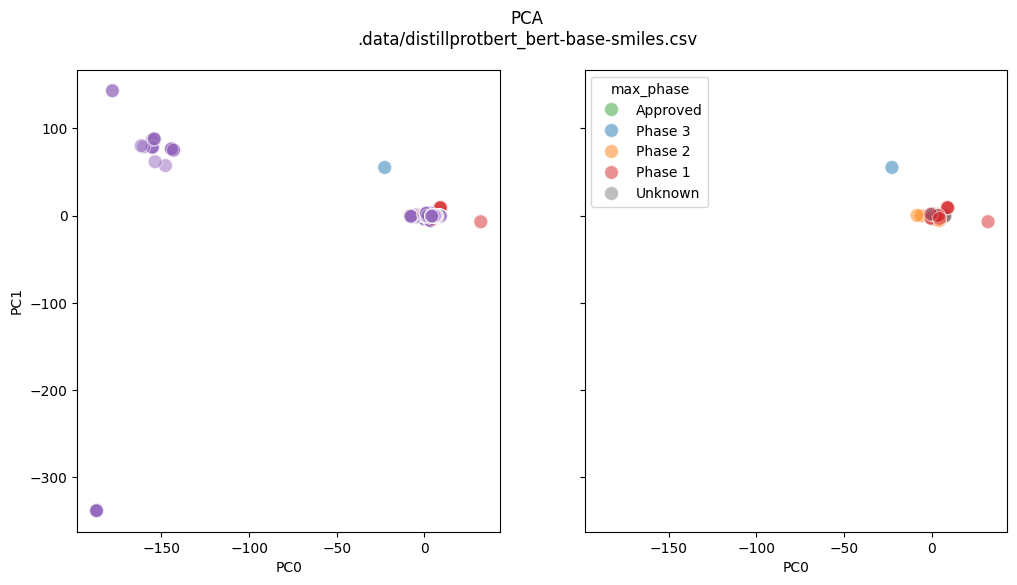

In [373]:
pca = PCAresult(df, feature_keys=DF_KEYS)
df_pca=pd.concat([df, pca.components_df], axis=1)
#pca.plot_pca_loadings()
print(pca.explained_variance_df)
plots,ax=plt.subplots(1,2,figsize=(12,6),sharex=True,sharey=True)
sns.scatterplot(data=df_pca, x="PC0", y="PC1",palette=PALETTE,hue=HUE, s=100,alpha=0.5,legend=False,ax=ax[0])
sns.scatterplot(data=df_pca[df_pca.max_phase!="Investigative"], x="PC0", y="PC1",palette=PALETTE,hue=HUE, s=100,alpha=0.5,legend=True,ax=ax[1])
plots.suptitle(f"PCA\n{file_path}")
plt.show()

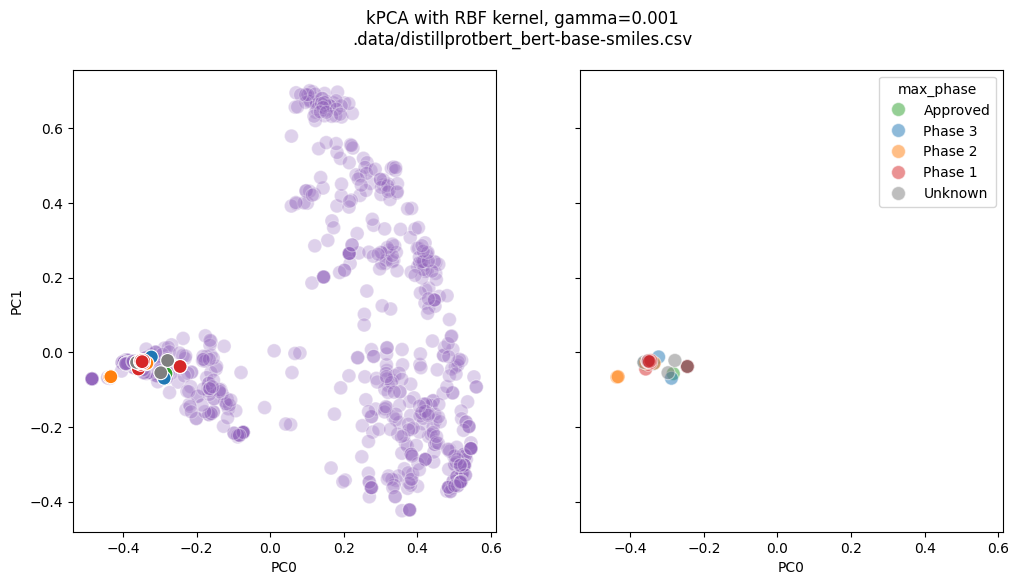

In [374]:
#??kPCAresult
gamma=0.001
kpca = kPCAresult(df, feature_keys=DF_KEYS, kernel="rbf", gamma=gamma)
df_kpca=pd.concat([df, kpca.components_df], axis=1)
plots,ax=plt.subplots(1,2,figsize=(12,6),sharex=True,sharey=True)
sns.scatterplot(data=df_kpca[df_kpca.max_phase=="Investigative"], x="PC0", y="PC1",palette=PALETTE,hue=HUE, s=100,alpha=0.3,legend=False,ax=ax[0])
sns.scatterplot(data=df_kpca[df_kpca.max_phase!="Investigative"], x="PC0", y="PC1",palette=PALETTE,hue=HUE, s=100,alpha=1.0,legend=False,ax=ax[0])
sns.scatterplot(data=df_kpca[df_kpca.max_phase!="Investigative"], x="PC0", y="PC1",palette=PALETTE,hue=HUE, s=100,alpha=0.5,legend=True,ax=ax[1])
plots.suptitle(f"kPCA with RBF kernel, gamma={gamma}\n{file_path}")
plt.show()

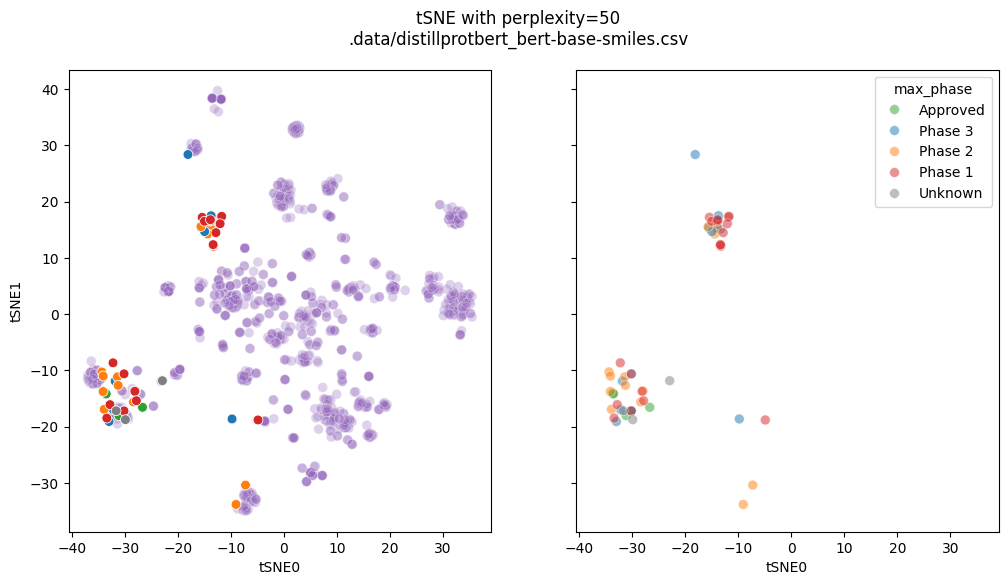

Init signature:
tSNEresult(
    df: pandas.core.frame.DataFrame,
    feature_keys: list[str],
    n_components: int = 2,
    use_pca: bool = False,
    pca_components: int = 50,
    perplexity: float = 30.0,
    random_state: int = 42,
) -> None
Source:        
class tSNEresult:
    """
    Container object for t-SNE results and associated plotting/projection methods.
    Optionally uses PCA for dimensionality reduction before applying t-SNE.
    """
    def __init__(self, df: pd.DataFrame, feature_keys: list[str], 
                 n_components: int = 2, use_pca: bool = False, 
                 pca_components: int = 50, perplexity: float = 30.0,
                 random_state: int = 42) -> None:
        """
        Constructor.
        Initialises the class and:
        - checks that feature_keys is a subset of df.columns (throws ValueError if not)
        - checks that df[feature_keys] does not contain NaN (throws ValueError if it does)
        
        Input:
              df: pd.Dat

In [375]:
??tSNEresult
perplexity=50
tsne = tSNEresult(df, feature_keys=DF_KEYS, n_components=2, perplexity=perplexity, use_pca=False, pca_components=10, random_state=42)
df_tsne=pd.concat([df, tsne.components_df], axis=1)
plots,ax=plt.subplots(1,2,figsize=(12,6),sharex=True,sharey=True)
sns.scatterplot(data=df_tsne[df_tsne.max_phase=="Investigative"], x="tSNE0", y="tSNE1",palette=PALETTE,hue=HUE, s=50,alpha=0.3,legend=False,ax=ax[0])
sns.scatterplot(data=df_tsne[df_tsne.max_phase!="Investigative"], x="tSNE0", y="tSNE1",palette=PALETTE,hue=HUE, s=50,alpha=1.0,legend=False,ax=ax[0])
sns.scatterplot(data=df_tsne[df_tsne.max_phase!="Investigative"], x="tSNE0", y="tSNE1",palette=PALETTE,hue=HUE, s=50,alpha=0.5,legend=True,ax=ax[1])
plots.suptitle(f"tSNE with perplexity={perplexity}\n{file_path}")
plt.show()

/Users/jclarknicholas/github/adc_developability/.conda/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


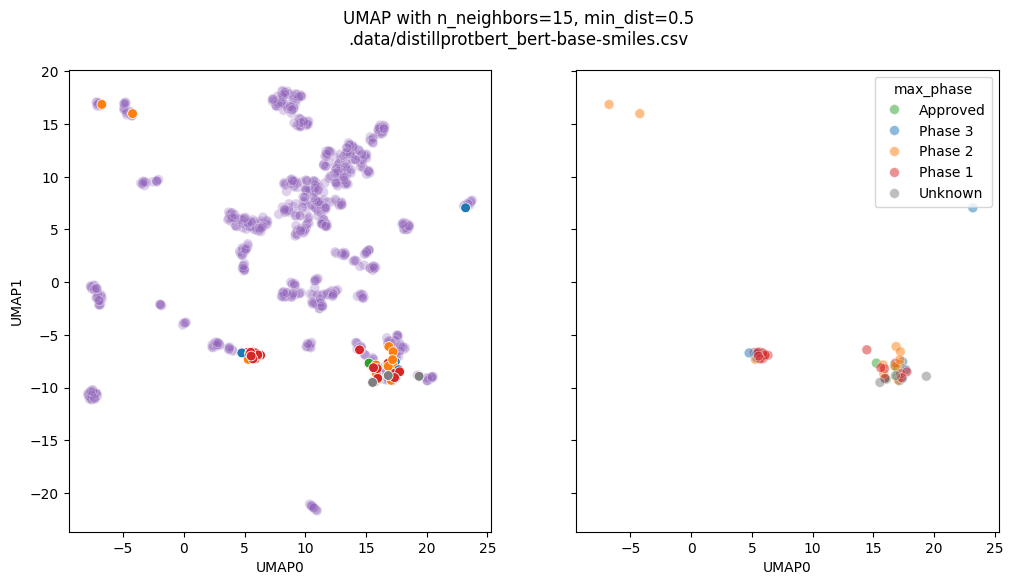

Init signature:
UMAPresult(
    df: pandas.core.frame.DataFrame,
    feature_keys: list[str],
    n_components: int = 2,
    use_pca: bool = False,
    pca_components: int = 50,
    n_neighbors: int = 15,
    min_dist: float = 0.1,
    random_state: int = 42,
) -> None
Source:        
class UMAPresult:
    """
    Container object for UMAP results and associated plotting/projection methods.
    Optionally uses PCA for dimensionality reduction before applying UMAP.
    """
    def __init__(self, df: pd.DataFrame, feature_keys: list[str], 
                 n_components: int = 2, use_pca: bool = False, 
                 pca_components: int = 50, n_neighbors: int = 15,
                 min_dist: float = 0.1, random_state: int = 42) -> None:
        """
        Constructor.
        Initialises the class and:
        - checks that feature_keys is a subset of df.columns (throws ValueError if not)
        - checks that df[feature_keys] does not contain NaN (throws ValueError if it does)
      

In [376]:
??UMAPresult
n_neighbors=15
min_dist=0.5
umap = UMAPresult(df, feature_keys=DF_KEYS, n_components=2, random_state=42,n_neighbors=n_neighbors, min_dist=min_dist)
df_umap=pd.concat([df, umap.components_df], axis=1)
plots,ax=plt.subplots(1,2,figsize=(12,6),sharex=True,sharey=True)
sns.scatterplot(data=df_umap[df_umap.max_phase=="Investigative"], x="UMAP0", y="UMAP1",palette=PALETTE,hue=HUE, s=50,alpha=0.3,legend=False,ax=ax[0])
sns.scatterplot(data=df_umap[df_umap.max_phase!="Investigative"], x="UMAP0", y="UMAP1",palette=PALETTE,hue=HUE, s=50,alpha=1.0,legend=False,ax=ax[0])
sns.scatterplot(data=df_umap[df_umap.max_phase!="Investigative"], x="UMAP0", y="UMAP1",palette=PALETTE,hue=HUE, s=50,alpha=0.5,legend=True,ax=ax[1])
plots.suptitle(f"UMAP with n_neighbors={n_neighbors}, min_dist={min_dist}\n{file_path}")
plt.show()